# Diffusion for Image Generation


## Speaker: Dr. Nimrita Koul

https://www.linkedin.com/in/nimritakoul/


### Install required libraries

In [ ]:
# Install lightweight, open-source generation packages
!pip install -q torch torchvision diffusers transformers accelerate safetensors

### Verify that the GPU instance is available





In [ ]:
# Cell 2: Verify GPU availability
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device connected: {device}")

if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: Running on CPU. Please switch Colab runtime to GPU (T4).")

Device connected: cuda
GPU Name: Tesla T4


### Load Open-Source Latent Diffusion Model Pipeline from HuggingFace

https://huggingface.co/


In [ ]:
# Cell 3: Load pretrained weights into memory
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

model_id = "runwayml/stable-diffusion-v1-5"

# Load pipeline in FP16 precision to fit free GPU VRAM
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
    safety_checker=None  # Saves VRAM & memory bandwidth for live demo
)

# Move pipeline to GPU
pipe = pipe.to(device)

print("Model successfully loaded into memory!")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Model successfully loaded into memory!


### Configure Fast ODE Sampler & Memory Optimizations
Demonstrates how to swap noise schedulers to lower NFE (Number of Function Evaluations) and optimize VRAM utilization.

In [ ]:
# Cell 4: Swap scheduler for faster inference & apply memory slicing
# Swapping to DPM-Solver++ reduces required sampling steps from 50 to 20
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

# Slice attention memory during execution to ensure smooth live screen sharing
if device == "cuda":
    pipe.enable_attention_slicing()

print(f"Scheduler configured: {pipe.scheduler.__class__.__name__}")

Scheduler configured: DPMSolverMultistepScheduler


### Define Prompts & Hyper-Parameters
Sets up conditional text inputs and sampling parameters for experimentation.

- Classifier-Free Guidance Experiment:  change guidance_scale from 1.0 (unconditioned/low alignment) to 7.5 (balanced) and 20.0 (over-conditioned/saturated) to see how CFG steers the reverse trajectory.


- NFE Complexity Trade-Off: Experiment with changing nfe_steps in Cell 5 from 5 to 20 to 50 to illustrate the trade-off between image detail quality and computational latency.



In [ ]:
# Cell 5: Set generation parameters
prompt = "A detailed diagram of a neural network floating in space, high quality, 8k"
negative_prompt = "blurry, low quality, distorted, ugly"

# Inference parameters
nfe_steps = 20          # Number of Function Evaluations (Inference steps)
guidance_scale = 7.5    # Classifier-Free Guidance (CFG) scale w

print(f"Prompt: '{prompt}'")
print(f"NFE Steps: {nfe_steps} | Guidance Scale (CFG): {guidance_scale}")

Prompt: 'A detailed diagram of a neural network floating in space, high quality, 8k'
NFE Steps: 20 | Guidance Scale (CFG): 7.5


### Run Sampling Trajectory & Render Output
Execute the reverse denoising process across the latent space and decodes the image via VAE.

Generating image...


  0%|          | 0/20 [00:00<?, ?it/s]

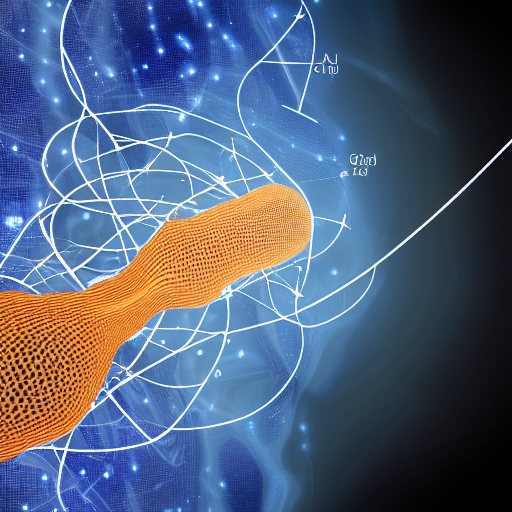

In [ ]:
# Cell 6: Run the reverse diffusion sampling process
print("Generating image...")

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=nfe_steps,
    guidance_scale=guidance_scale
).images[0]

# Display the generated image
image